# PROJETO 1 ANADI - E-REDES

In [1]:
# TODOS OS IMPORTS SÃO FEITOS AQUI PARA MANTER SIMPLICIDADE
# BIBLIOTECAS DISPONÍVEIS:
#   - matplotlib
#   - pandas
#   - numpy
#   - scipy

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ip_data = pd.read_excel("./data/IP_data.xlsx")
ptd_data = pd.read_excel("./data/PTD_data.xlsx")

### 1- Processamento da Iluminação Pública (IP_Data)

In [2]:
def is_inefficient(type: str) -> int:
    """
    Uma lâmpada é considerada ineficente se for de sódio
    ou de mercúrio 
    """
    return int(type in ["Sódio", "Mercúrio"]);

# Variavel `Is_Ineficiente`, indica e eficiencia de uma lampada
ip_data["Is_Ineficiente"] = ip_data["Tipo de Lâmpada"].apply(is_inefficient);

In [3]:
def power(total_power: float) -> float:
    """
    Calcula a potência em kW
    Para tal recebe a potência total instalada (em W) e divide a por 1000
    P = (pW / 1000) / 1000
    """
    return total_power / 10000;

ip_data["Pot_Kw"] = ip_data["Potência Instalada Total (W)"].apply(power);

In [4]:
# Soma da Potência kW de todas as linhas de IP do concelho
p_ip_total = ip_data.groupby("CodDistritoConcelho")["Pot_Kw"].sum();

# Soma da Potência kW das linhas onde Is_Ineficiente == 1
p_ip_inef = (
    ip_data[ip_data["Is_Ineficiente"] == 1]
    .groupby("CodDistritoConcelho")["Pot_Kw"]
    .sum()
);

result = pd.DataFrame({
    "P_IP_Total": p_ip_total,
    "P_IP_Inef": p_ip_inef
}).fillna(0);

print(result)

                     P_IP_Total  P_IP_Inef
CodDistritoConcelho                       
101                    91.08877    24.4320
102                    45.17118     2.8020
103                    65.70718     7.3545
104                    58.59744    11.5720
105                   105.51920    14.4420
...                         ...        ...
1820                   16.93978     2.8640
1821                   76.98269    11.6075
1822                   14.50096     2.0555
1823                  224.92599    69.2979
1824                   17.88920     0.0000

[278 rows x 2 columns]


### 2- Processamento dos Postos de Transformação (PTD data)

In [5]:
def parse_usage(usage: str) -> float:
    """
    Converter o nível de utilização num número decimal
    Exemplo: '60%-79%' -> 0.79
    Pelo que consigo ver o formato pode tomar os seguintes formatos:
    - 'X%-Y%'
    - +100%
    - N/D
    Não temos instruções de o que fazer por isso vou assumir que N/D -> NaN
    """
    if usage == "+100%":
        return 1;

    if '-' in usage:
        last_number: str = usage.split("-")[1].removesuffix("%");
        return int(last_number) / 100;

    return np.nan;

ptd_data["Nível de Utilização [%]"] = ptd_data["Nível de Utilização [%]"].apply(parse_usage);

In [6]:
# Cap_PTD: Soma da potência instalada [kVA] de todos os PTDs do concelho
# Util_Media: Média do nível de utilização dos PTDs do concelho
# N_PTDs: Número de PTDs nesse concelho
ptd_stats = ptd_data.groupby("CodDistritoConcelho").agg(
    Cap_PTD=("Potência instalada [kVA]", "sum"),
    Util_Media=("Nível de Utilização [%]", "mean"),
    N_PTDs=("CodDistritoConcelho", "count")
);

print(ptd_stats)

                     Cap_PTD  Util_Media  N_PTDs
CodDistritoConcelho                             
101                   105715    0.477593     388
102                    54540    0.469948     194
103                    55628    0.543009     223
104                    41884    0.527387     236
105                   197485    0.475475     509
...                      ...         ...     ...
1820                   11820    0.619219      66
1821                   46645    0.530407     274
1822                   11995    0.520933      79
1823                  228706    0.537171     789
1824                   20160    0.520420     150

[278 rows x 3 columns]


### 3- Variáveis do Novo Dataset

Com os dados calculados anteriormente, vamos definir um novo dataset com:
- Ganho LED (∆PLED ): Representa a potência a ser libertada pela substituição de lâmpadas ineficientes por tecnologia LED.
- Folga Rede (PFolga): Estima a capacidade disponível na rede, descontando a utilização atual e aplicando uma margem de segurança de 92%.
- Carga VE (PVE ): Projeta o aumento de carga necessário para instalar carregadores de 22 kW em todos os PTDs do concelho.
- Saldo Final de Viabilidade (D): O indicador que subtrai a nova carga (PVE) à capacidade total disponível (PFolga + ∆PLED ), determinando se o projeto é viável.
- Rate Ineficiencia: O rácio que mede o peso da tecnologia obsoleta face ao total da iluminação do concelho.

In [7]:
# Create an empty DataFrame using the municipalities from p_ip_inef as rows
resulting_data: pd.DataFrame = pd.DataFrame(index=p_ip_inef.index)

In [8]:
LED_SAVINGS_FACTOR = 0.65         # 65% reduction when replacing inefficient lamps
GRID_MARGIN = 0.92                # 92% of transformer capacity is considered usable
EV_CHARGER_POWER = 22             # kW per EV charger
EV_SIMULT_FACTOR = 0.6            # simultaneity factor for EV chargers

resulting_data["Ganho LED"] = p_ip_inef * LED_SAVINGS_FACTOR
resulting_data["Folga Rede"] = (ptd_stats["Cap_PTD"] * GRID_MARGIN) * (1 - ptd_stats["Util_Media"])
resulting_data["Carga VE"] = ptd_stats["N_PTDs"] * EV_CHARGER_POWER * EV_SIMULT_FACTOR
resulting_data["Saldo Final de Viabilidade"] = (
    resulting_data["Folga Rede"] + resulting_data["Ganho LED"] - resulting_data["Carga VE"]
)
resulting_data["Rate Ineficiencia"] = p_ip_inef / p_ip_total

print(resulting_data)

                     Ganho LED    Folga Rede  Carga VE  \
CodDistritoConcelho                                      
101                  15.880800  50808.195148    5121.6   
102                   1.821300  26596.303834    2560.8   
103                   4.780425  23387.762452    2943.6   
104                   7.521800  18211.314133    3115.2   
105                   9.387300  95298.999935    6718.8   
...                        ...           ...       ...   
1819                  1.188200   4204.740941     924.0   
1820                  1.861600   4140.767625     871.2   
1821                  7.544875  20151.814763    3616.8   
1822                  1.336075   5286.692293    1042.8   
1823                 45.043635  97383.670802   10414.8   

                     Saldo Final de Viabilidade  Rate Ineficiencia  
CodDistritoConcelho                                                 
101                                45702.475948           0.268222  
102                                240

### 4.3 - Análise e Exploração de Dados

1- Construa uma representação gráfica que permita visualizar o mix tecnológico (LED vs. Convencional). Identifique se a maioria da potência ineficiente se concentra num grupo restrito de municípios.

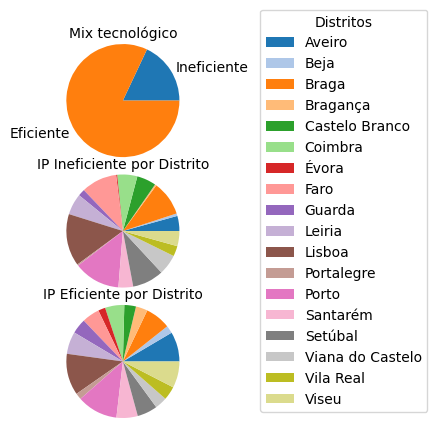

In [9]:
fig, ax = plt.subplots(3, 1)

inefficient = np.array(ip_data[ip_data["Is_Ineficiente"] == 1].groupby("CodDistrito")["Luminárias"].sum())
efficient = np.array(ip_data[ip_data["Is_Ineficiente"] == 0].groupby("CodDistrito")["Luminárias"].sum())

# I can't stress enough how impossible it is to turn the below array of "stringarrays" into a normal array of strings.
#labels = np.array(ip_data[ip_data["Is_Ineficiente"] == 1].groupby("CodDistrito")["Distrito"].unique())
# So we're doing this instead.
labels = ["Aveiro", "Beja", "Braga", "Bragança", "Castelo Branco", "Coimbra", "Évora", "Faro", "Guarda", "Leiria", "Lisboa", "Portalegre", "Porto", "Santarém", "Setúbal", "Viana do Castelo", "Vila Real", "Viseu"]
joined = np.concatenate((inefficient, efficient))

tab20 = plt.color_sequences["tab20"]
ax[0].pie([np.sum(inefficient), np.sum(efficient)], labels=["Ineficiente", "Eficiente"], radius=1.3)
ax[0].set_title("Mix tecnológico", fontsize=10)
ax[1].pie(inefficient, colors=tab20, radius=1.3)
ax[1].set_title("IP Ineficiente por Distrito", fontsize=10)
wedges, texts = ax[2].pie(efficient, colors=tab20, radius=1.3)
ax[2].set_title("IP Eficiente por Distrito", fontsize=10)

ax[0].legend(wedges, labels, title="Distritos", bbox_to_anchor=(1.7, 0, 0, 1.4))

plt.show()

Os dados grafados acima demonstram muito claramente que a potência usada em iluminação ineficiente não é concentrada desproporcionalmente em um grupo particular de municípios: É distribuída, de um modo muito semelhante á distribuição da potência usada em iluminação eficiente, ao longo do país.

2- Construa boxplots para comparar as distribuições dos níveis de utilização dos PTDs entre os distritos de Lisboa, Porto, Aveiro e Setúbal. Identifique o distrito com maior variabilidade de carga.

[0.39 0.19 0.39 ... 0.19 0.19 0.59]
[0.79 0.79 0.79 ... 0.19 0.19  nan]
[0.39 0.19 0.19 ... 0.39 0.59 0.59]
[0.59 0.59 0.79 ... 0.59 0.19 0.39]


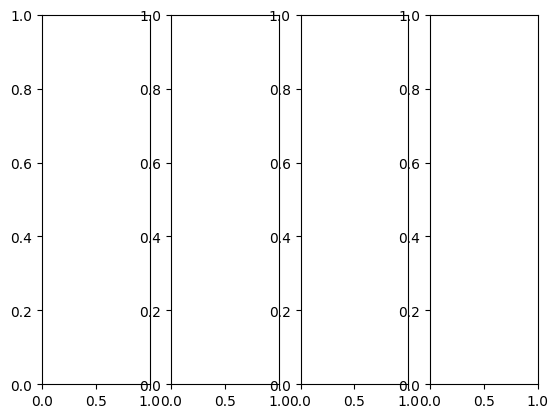

In [26]:
fig, ax = plt.subplots(1,4)

# DISTRITOS:
# Lisboa - 11
# Porto - 13
# Aveiro - 1
# Setúbal - 15
# O código de concelho é constituido pelo código do distrito + dois dígitos: Ao remover estes, podemos identificar o distrito do concelho

lisboa_data = ptd_data[np.logical_and(ptd_data["CodDistritoConcelho"] > 1100, ptd_data["CodDistritoConcelho"] < 1200)]["Nível de Utilização [%]"].to_numpy()
porto_data = ptd_data[np.logical_and(ptd_data["CodDistritoConcelho"] > 1300, ptd_data["CodDistritoConcelho"] < 1400)]["Nível de Utilização [%]"].to_numpy()
aveiro_data = ptd_data[np.logical_and(ptd_data["CodDistritoConcelho"] > 100, ptd_data["CodDistritoConcelho"] < 200)]["Nível de Utilização [%]"].to_numpy()
setubal_data = ptd_data[np.logical_and(ptd_data["CodDistritoConcelho"] > 1500, ptd_data["CodDistritoConcelho"] < 1600)]["Nível de Utilização [%]"].to_numpy()

print(lisboa_data)
print(porto_data)
print(aveiro_data)
print(setubal_data)
# now figure out how to make the boxplots

plt.show()

3- Quantifique a prevalência de valores omissos ou indeterminados (N/D, <20). Utilize uma representação gráfica para identificar a presença de outliers nos níveis de ocupação da rede.

In [11]:
# 3 goes here

4- Construa uma tabela com a média, quartis, desvio padrão, assimetria e curtose do nível de utilização médio para os concelhos de Coimbra, Évora, Braga e Faro (apresente com 4 casas decimais).

In [12]:
# 4 goes here

### 4.4 - Inferência Estatística

1- Considere a base de dados consolidada e selecione aleatoriamente uma amostra de 50 concelhos. Use esta amostra para testar se o nível médio de ocupação da rede é inferior a um patamar de referência (ex: 60\%), verificando previamente a normalidade dos dados.

In [13]:
# 1 goes here

2- Selecione aleatoriamente duas amostras de 30 registos: uma de concelhos "Modernizados" (rácio de LED acima da mediana) e outra de concelhos "Ineficientes". Use estas amostras para testar se o estado médio de ocupação da rede difere significativamente entre os dois grupos.

In [14]:
# 2 goes here

3- Considere três amostras aleatórias de 25 concelhos representativas de diferentes perfis de ocupação da rede: Norte/Centro Litoral (Porto, Braga, Coimbra), Lisboa e Litoral Sul (Lisboa, Setúbal, Aveiro) e Interior/Alentejo (Évora, Beja, Portalegre). Use estas amostras para testar a existência de diferenças significativas nos níveis médios de carga da rede (ANOVA). Caso necessário, efetue uma análise post-hoc adequada

In [15]:
# 3 goes here

4- Teste a existência de uma relação linear estatisticamente significativa entre a capacidade total de transformação instalada e a carga de iluminação pública para a totalidade dos concelhos, interpretando o coeficiente de correlação de Pearson

In [16]:
# 4 goes here

### 4.5 - Correlação e Regressão - Modelo Preditivo

Considere os dados relativos aos níveis médios de carga dos PTDs nos distritos de Aveiro, Porto, Lisboa e Braga e construa uma tabela de correlação entre as principais métricas de infraestrutura (Capacidade PTD e Potência IP) para estes distritos. Selecione os dados relativos a Portugal Continental. Considere as seguintes variáveis explicativas:

- X1 – Potência Instalada Total de Iluminação Pública ***(P_IP_Total)***
- X2 – Capacidade Nominal de Transformação ***(Cap_PTD)***
- X3 – Ineficiência ***(Rate_Ineficencia)***

e a variável dependente:

- Y – Estado de Ocupação Médio da Rede ***(Util_Media)***.

1- Determine o modelo de regressão linear múltipla que explique a variação de Y em função de X1, X2 e X3.

In [17]:
# 1 goes here

2- Verifique as condições sobre os resíduos (normalidade, independência e homocedasticidade).

In [18]:
# 2 goes here

3- Verifique se existe multicolinearidade entre as variáveis recorrendo ao cálculo do VIF *(Variance Inflation Factor)*.

In [19]:
# 3 goes here

4- Comente o modelo obtido tendo em conta o coeficiente de determinação ajustado e a significância estatística dos preditores.

In [20]:
# 4 goes here

5- Estime o nível de ocupação esperado (Y) para os concelhos com os códigos: 101, 102, 103, 104, 105, 106, 107, 108 e 109 (Distrito de Aveiro) e compare as previsões com os valores reais presentes no dataset.

In [21]:
# 5 goes here

6- Com base no coeficiente β3 obtido no modelo, quantifique a redução esperada no nível de ocupação da rede caso o rácio de ineficiência tecnológica seja reduzido em 20\% através da implementação de tecnologia LED.

In [22]:
# 6 goes here

7- Utilize o modelo para identificar os concelhos onde a libertação de potência é estatisticamente mais viável para a instalação de carregadores de veículos elétricos de 22 kW, justificando com base nos intervalos de confiança das previsões.

In [23]:
# 7 goes here

### 4.6 - Análise e Discussão de Resultados

Efetue uma síntese dos resultados e das conclusões, obtidos neste trabalho, que considera mais importantes, justificando sempre que necessário (conclusão). Use um nível de significância de 5% em todos os testes de hipótese que realizar.